 <h2 align="center">E-Commerce Analytics EDA</h2>

### project = E-Commerce Analytics EDA

#### Author - Ajeet kumar
#### Data science aspirant

# About the Dataset

## Major E-Commerce Analytics Project

This project is based on a large-scale **E-Commerce dataset** created for practicing real-world data analysis using Python, Pandas, Matplotlib, and Seaborn.

The dataset contains multiple interconnected tables representing different aspects of an online shopping platform, including customers, products, orders, order items, payments, and customer reviews.

The main objective of this project is to simulate a real-world business analytics environment where raw and imperfect data must be cleaned, transformed, combined, analyzed, and converted into meaningful business insights.

## Dataset Structure

The project contains six relational tables:

* **Customers** – Contains customer demographic and registration information.
* **Products** – Contains product details, categories, brands, prices, stock, and suppliers.
* **Orders** – Contains order-level information such as customers, dates, status, coupons, discounts, and delivery time.
* **Order Items** – Contains individual products and quantities associated with each order.
* **Payments** – Contains payment methods, payment status, payment dates, and transaction amounts.
* **Reviews** – Contains customer ratings, review dates, and review text.

## Relationships Between Tables

The tables are connected through primary and foreign keys.

```text
Customers
    │
    │ customer_id
    ↓
Orders
    │
    ├──────────────→ Payments
    │
    ├──────────────→ Reviews
    │
    ↓
Order_Items
    │
    │ product_id
    ↓
Products
```

These relationships allow us to perform different types of joins and create a combined dataset for deeper analysis.

## Data Quality Challenges

To make the project similar to a real-world data analytics task, the raw dataset intentionally contains several data-quality problems, including:

* Missing values
* Duplicate records
* Invalid foreign keys
* Incorrect data types
* Invalid dates
* Negative quantities and amounts
* Extreme outliers
* Inconsistent category names
* Inconsistent payment methods
* Invalid ratings
* Incorrect or unusual values

The purpose is to identify these issues using Python and apply appropriate data-cleaning techniques rather than simply removing problematic records.

## Project Objectives

The major objectives of this project are:

1. Understand the structure and quality of the raw data.
2. Clean and preprocess all datasets.
3. Identify and handle missing and duplicate values.
4. Detect and handle outliers and invalid records.
5. Perform different types of joins using Pandas.
6. Create meaningful features for analysis.
7. Analyze sales, customers, products, payments, and reviews.
8. Create meaningful visualizations.
9. Extract important business insights.
10. Build a complete end-to-end E-Commerce analytics project.

## Tools and Technologies

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Jupyter Notebook

## Final Goal

The final goal of this project is to transform raw, messy E-Commerce data into a **clean, analysis-ready dataset** and use it to answer important business questions related to sales performance, customer behavior, product performance, payments, discounts, delivery, and customer satisfaction.


## Import Libraries


#### We will use the following libraries

1. Pandas: Data manipulation and analysis¶

2. Numpy: Numerical operations and calculations

3. Matplotlib: Data visualization and plotting

4. Seaborn: Enhanced data visualization and statistical graphics



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading and Exploration | Cleaning

#### Loading the csv file

In [3]:
df_customer = pd.read_csv("/Users/ajeetkumar/Desktop/major_ecommerce_analytics_project/customers.csv")
df_order_item = pd.read_csv("/Users/ajeetkumar/Desktop/major_ecommerce_analytics_project/order_items.csv")
df_order = pd.read_csv("/Users/ajeetkumar/Desktop/major_ecommerce_analytics_project/orders.csv")
df_payment = pd.read_csv("/Users/ajeetkumar/Desktop/major_ecommerce_analytics_project/payments.csv")
df_product = pd.read_csv("/Users/ajeetkumar/Desktop/major_ecommerce_analytics_project/products.csv")
df_review = pd.read_csv("/Users/ajeetkumar/Desktop/major_ecommerce_analytics_project/reviews.csv")

#### cleaning table one by one

### use customer table

#### Set option to see max columns

In [4]:
pd.set_option('display.max_columns', None) 

### Get a sneak peek of data

The purpose of a sneak peek is to get a quick overview of the data and identify any potential problems or areas of interest.

In [5]:
df_customer.head()

,customer_id,customer_name,gender,age,city,state,signup_date,customer_segment
0,100001,Amit Mishra,Female,41.0,Gurgaon,Haryana,2023-11-28,Regular
1,100002,Sanjay Roy,Female,31.0,Kolkata,West Bengal,2025-06-28,Premium
2,100003,Sneha Sharma,female,66.0,Indore,Madhya Pradesh,2021-08-02,New
3,100004,Nisha Jain,Female,35.0,Indore,Madhya Pradesh,2025-10-06,Regular
4,100005,Rohit Jain,Male,21.0,Kanpur,Uttar Pradesh,2024-11-15,Premium


### Lets see the columns name

In [6]:
df_customer.columns

Index(['customer_id', 'customer_name', 'gender', 'age', 'city', 'state',
       'signup_date', 'customer_segment'],
      dtype='object')

### Lets see the shape of the table

In [7]:
df_customer.shape

(20150, 8)

### Let's have a look on the columns and their data types using detailed info function

In [8]:
df_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20150 entries, 0 to 20149
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20150 non-null  int64  
 1   customer_name     20150 non-null  object 
 2   gender            18941 non-null  object 
 3   age               19752 non-null  float64
 4   city              19897 non-null  object 
 5   state             20150 non-null  object 
 6   signup_date       20150 non-null  object 
 7   customer_segment  20150 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 1.2+ MB


### check for null value

In [9]:
df_customer.isna().sum()

customer_id            0
customer_name          0
gender              1209
age                  398
city                 253
state                  0
signup_date            0
customer_segment       0
dtype: int64

### Check for duplicate row

In [10]:
df_customer.duplicated().sum()

np.int64(150)

### Check for data consistancy

In [11]:
for i in ("gender" , "city" , "state" , "customer_segment"):
    print(i)
    print(df_customer[i].unique())
    print(df_customer[i].nunique())
    print()
    print("-"* 70)

gender
['Female' 'female' 'Male' 'male' 'M' nan 'F']
6

----------------------------------------------------------------------
city
['Gurgaon' 'Kolkata' 'Indore' 'Kanpur' 'Bengaluru' 'Ahmedabad' 'Noida'
 'Delhi' 'Patna' 'Chandigarh' 'Surat' 'Pune' 'Nagpur' 'Jaipur' 'Lucknow'
 'Mumbai' nan 'Chennai' 'Bhopal' 'Hyderabad' 'Ranchi']
20

----------------------------------------------------------------------
state
['Haryana' 'West Bengal' 'Madhya Pradesh' 'Uttar Pradesh' 'Karnataka'
 'Gujarat' 'Delhi' 'Bihar' 'Chandigarh' 'Maharashtra' 'Rajasthan'
 'Tamil Nadu' 'Telangana' 'Delhi ' 'Jharkhand']
15

----------------------------------------------------------------------
customer_segment
['Regular' 'Premium' 'New' 'VIP']
4

----------------------------------------------------------------------



<h2 align="center">Observation No 1</h2>

#### 1 -> There are 20150 rows and 8 columns in this tables

#### 2-> Columns of this tables are 'customer_id', 'customer_name', 'gender', 'age', 'city', 

#### 'state','signup_date', 'customer_segment
       
#### 3 -> Except customer_id & signup date columns all columns data are in object form

#### 4 -> There are some null values in Age , Gender , and city columns

#### 5 -> 150 rows are duplicate

#### 6 -> Categorical columns contain inconsistent representations of the same categories, 

#### especially Gender and State. These values should be standardized before performing analysis.



### Move to data cleaning process

#### 1 - Changing Data Types of Columns in required form

In [12]:
df_customer["customer_id"] = df_customer["customer_id"].astype("int64")

In [13]:
df_customer["signup_date"] = pd.to_datetime(df_customer["signup_date"])

In [14]:
# see the changed datatypes
df_customer.dtypes

customer_id                  int64
customer_name               object
gender                      object
age                        float64
city                        object
state                       object
signup_date         datetime64[ns]
customer_segment            object
dtype: object

### 2 - Deal with duplicates rwo

In [15]:
df_customer.duplicated().sum()
# there are the no of duplicated rows

np.int64(150)

In [16]:
df_customer[df_customer.duplicated()]
# These are the duplicates row

,customer_id,customer_name,gender,age,city,state,signup_date,customer_segment
20000,111457,Sneha Verma,Female,42.0,Lucknow,Uttar Pradesh,2024-12-25,Premium
20001,116529,Sneha Sharma,F,45.0,Kanpur,Uttar Pradesh,2022-12-12,Regular
20002,103254,Sanjay Mishra,Male,68.0,Surat,Gujarat,2023-12-13,Premium
20003,118615,Manish Agarwal,Female,33.0,Lucknow,Uttar Pradesh,2021-01-08,Regular
20004,101545,Nisha Thakur,Male,50.0,Jaipur,Rajasthan,2021-11-18,Regular
...,...,...,...,...,...,...,...,...
20145,103302,Sneha Mishra,Female,39.0,Chennai,Tamil Nadu,2024-07-12,Premium
20146,116582,Kavita Jain,Female,63.0,Noida,Uttar Pradesh,2024-04-10,Regular
20147,119851,Aditya Reddy,Female,48.0,Gurgaon,Haryana,2024-07-18,New
20148,103096,Anjali Singh,male,32.0,Delhi,Delhi,2021-04-10,Premium


In [17]:
df_customer[df_customer["customer_id"] == 111457]
# we can see the duplicated rows

,customer_id,customer_name,gender,age,city,state,signup_date,customer_segment
11456,111457,Sneha Verma,Female,42.0,Lucknow,Uttar Pradesh,2024-12-25,Premium
20000,111457,Sneha Verma,Female,42.0,Lucknow,Uttar Pradesh,2024-12-25,Premium


In [18]:
# now its time to remove all the duplicated rows
df_customer= df_customer.drop_duplicates()


### 3 . deal with null value

In [19]:
# firstly will see the no of null values

df_customer.isna().sum()


customer_id            0
customer_name          0
gender              1202
age                  397
city                 250
state                  0
signup_date            0
customer_segment       0
dtype: int64

In [20]:
# percentage of null value so we will decide what we have to do with missing value

df_customer.isna().sum() * 100 / len(df_customer)

customer_id         0.000
customer_name       0.000
gender              6.010
age                 1.985
city                1.250
state               0.000
signup_date         0.000
customer_segment    0.000
dtype: float64

### plot the missing age histogram and check its distribution

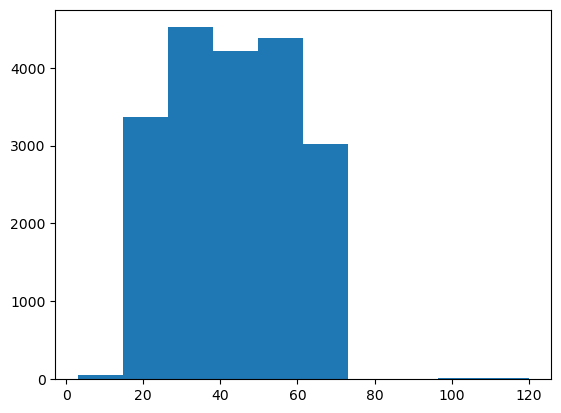

In [21]:
plt.hist(df_customer["age"])
plt.show()

##### from histogram its cleared the age data is normal distributed so
##### we will fill the null value as 

##### Age -> Mean
##### City -> Mode
##### Gender -> Mode

### Fill the null values

In [22]:
for i in ("city" , "gender"):
    df_customer[i] = df_customer[i].fillna(df_customer[i].mode()[0])

In [23]:
df_customer["age"] = df_customer["age"].fillna(df_customer["age"].mean())

In [24]:
# check the null value
df_customer.isnull().sum()

customer_id         0
customer_name       0
gender              0
age                 0
city                0
state               0
signup_date         0
customer_segment    0
dtype: int64

### Deal with inconsistent value

In [25]:
for i in ("gender" , "city" , "state" , "customer_segment"):
    print(i)
    print(df_customer[i].unique())
    print(df_customer[i].nunique())
    print()
    print("-"* 70)

gender
['Female' 'female' 'Male' 'male' 'M' 'F']
6

----------------------------------------------------------------------
city
['Gurgaon' 'Kolkata' 'Indore' 'Kanpur' 'Bengaluru' 'Ahmedabad' 'Noida'
 'Delhi' 'Patna' 'Chandigarh' 'Surat' 'Pune' 'Nagpur' 'Jaipur' 'Lucknow'
 'Mumbai' 'Chennai' 'Bhopal' 'Hyderabad' 'Ranchi']
20

----------------------------------------------------------------------
state
['Haryana' 'West Bengal' 'Madhya Pradesh' 'Uttar Pradesh' 'Karnataka'
 'Gujarat' 'Delhi' 'Bihar' 'Chandigarh' 'Maharashtra' 'Rajasthan'
 'Tamil Nadu' 'Telangana' 'Delhi ' 'Jharkhand']
15

----------------------------------------------------------------------
customer_segment
['Regular' 'Premium' 'New' 'VIP']
4

----------------------------------------------------------------------


In [26]:
# Replace F to female and M to male in gender columns ans standarize in gender column
# standarize
df_customer["gender"] =df_customer["gender"].str.title()
# rename f to female and m to male
df_customer["gender"] = df_customer["gender"].replace({"F":"Female" , "M" : "Male"})

# Remove the extra space in state columns

df_customer["state"]= df_customer["state"].str.strip()



#### Check

In [27]:
df_customer.isnull().sum()

customer_id         0
customer_name       0
gender              0
age                 0
city                0
state               0
signup_date         0
customer_segment    0
dtype: int64

In [28]:
df_customer.duplicated().sum()

np.int64(0)

In [29]:
df_customer.dtypes

customer_id                  int64
customer_name               object
gender                      object
age                        float64
city                        object
state                       object
signup_date         datetime64[ns]
customer_segment            object
dtype: object

In [30]:
for i in ("gender" , "city" , "state" , "customer_segment"):
    print(i)
    print(df_customer[i].unique())
    print(df_customer[i].nunique())
    print()
    print("-"* 70)

gender
['Female' 'Male']
2

----------------------------------------------------------------------
city
['Gurgaon' 'Kolkata' 'Indore' 'Kanpur' 'Bengaluru' 'Ahmedabad' 'Noida'
 'Delhi' 'Patna' 'Chandigarh' 'Surat' 'Pune' 'Nagpur' 'Jaipur' 'Lucknow'
 'Mumbai' 'Chennai' 'Bhopal' 'Hyderabad' 'Ranchi']
20

----------------------------------------------------------------------
state
['Haryana' 'West Bengal' 'Madhya Pradesh' 'Uttar Pradesh' 'Karnataka'
 'Gujarat' 'Delhi' 'Bihar' 'Chandigarh' 'Maharashtra' 'Rajasthan'
 'Tamil Nadu' 'Telangana' 'Jharkhand']
14

----------------------------------------------------------------------
customer_segment
['Regular' 'Premium' 'New' 'VIP']
4

----------------------------------------------------------------------


### Now our data is cleaned , consistent ,having no duplicated data and having proper data type

### use order_item tables

#### Get a sneak peek of data¶

In [31]:
df_order_item.head()

,order_item_id,order_id,product_id,quantity
0,900001,500001,1241,2
1,900002,500002,1733,3
2,900003,500003,1444,1
3,900004,500004,1852,1
4,900005,500004,1561,3


#### check datatype and info

In [32]:
df_order_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155523 entries, 0 to 155522
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   order_item_id  155523 non-null  int64
 1   order_id       155523 non-null  int64
 2   product_id     155523 non-null  int64
 3   quantity       155523 non-null  int64
dtypes: int64(4)
memory usage: 4.7 MB


#### Check for null value

In [33]:
df_order_item.isnull().sum()

order_item_id    0
order_id         0
product_id       0
quantity         0
dtype: int64

#### checks for duplicated row

In [34]:
df_order_item.duplicated().sum()

np.int64(500)

#### check shape

In [35]:
df_order_item.shape

(155523, 4)

#### columns name

In [36]:
df_order_item.columns

Index(['order_item_id', 'order_id', 'product_id', 'quantity'], dtype='object')

<h2 align="center">Observation No 2</h2>


#### in df_order_item table we have 4 columns and 155523 rows
#### data are fully consistent
#### there are 500 duplicated data 

#### ** cleaning process

#### Remove duplicate value

In [37]:
df_order_item.duplicated().sum()

# no of duplicate value = 

np.int64(500)

In [38]:
df_order_item[df_order_item.duplicated()]
# see the row of duplicate value

,order_item_id,order_id,product_id,quantity
155023,1053023,598714,1610,3
155024,937274,524085,1321,3
155025,1044031,592944,1407,3
155026,959852,538693,1496,3
155027,1044216,593060,1366,10
...,...,...,...,...
155518,1015020,574271,1715,1
155519,956505,536508,1459,1
155520,901556,501014,1597,4
155521,1024414,580323,1137,4


In [39]:
df_order_item = df_order_item.drop_duplicates()
# Removing the duplicate value

#### checks 


In [40]:
df_order_item.isnull().sum()

order_item_id    0
order_id         0
product_id       0
quantity         0
dtype: int64

In [41]:
df_order_item.duplicated().sum()

np.int64(0)

In [42]:
df_order_item.info()

<class 'pandas.core.frame.DataFrame'>
Index: 155023 entries, 0 to 155022
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   order_item_id  155023 non-null  int64
 1   order_id       155023 non-null  int64
 2   product_id     155023 non-null  int64
 3   quantity       155023 non-null  int64
dtypes: int64(4)
memory usage: 5.9 MB


### We can now say all data are consistent , no duplicate row , and all datatypes are in proper form

### use df_order table

In [43]:
df_order.shape

(100300, 9)

In [44]:
df_order.columns

Index(['order_id', 'customer_id', 'order_date', 'shipping_city',
       'shipping_state', 'order_status', 'coupon_code', 'discount_pct',
       'delivery_days'],
      dtype='object')

In [45]:
df_order.isna().sum()

order_id              0
customer_id           0
order_date            0
shipping_city         0
shipping_state        0
order_status       2990
coupon_code       10043
discount_pct          0
delivery_days         0
dtype: int64

In [46]:
df_order.duplicated().sum()

np.int64(300)

In [47]:
df_order.dtypes

order_id           int64
customer_id        int64
order_date        object
shipping_city     object
shipping_state    object
order_status      object
coupon_code       object
discount_pct       int64
delivery_days      int64
dtype: object

In [48]:
df_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100300 entries, 0 to 100299
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   order_id        100300 non-null  int64 
 1   customer_id     100300 non-null  int64 
 2   order_date      100300 non-null  object
 3   shipping_city   100300 non-null  object
 4   shipping_state  100300 non-null  object
 5   order_status    97310 non-null   object
 6   coupon_code     90257 non-null   object
 7   discount_pct    100300 non-null  int64 
 8   delivery_days   100300 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 6.9+ MB


In [49]:
for i in ("shipping_state" , "shipping_city" , "order_status"):
    print(i)
    print(df_order[i].unique())
    print()
    print("-" * 50)

shipping_state
['Maharashtra' 'Madhya Pradesh' 'Uttar Pradesh' 'Gujarat' 'Chandigarh'
 'Tamil Nadu' 'Delhi' 'Rajasthan' 'Karnataka' 'Telangana' 'Jharkhand'
 'West Bengal' 'Haryana' 'Bihar']

--------------------------------------------------
shipping_city
['Jaipur' 'Chandigarh' 'Kanpur' 'Mumbai' 'Indore' 'Noida' 'Chennai'
 'Nagpur' 'Bhopal' 'Patna' 'Ahmedabad' 'Delhi' 'Surat' 'Lucknow'
 'Bengaluru' 'Ranchi' 'Hyderabad' 'Gurgaon' 'Kolkata' 'Pune']

--------------------------------------------------
order_status
['Delivered' 'Shipped' 'Returned' 'Cancelled' 'delivered' 'Processing'
 'Pending' 'CANCELLED' nan]

--------------------------------------------------


<h2 align="center">Observation No 3</h2>

#### 1 . There are 100300 row and 9 columns
#### 2 . columns are ['order_id', 'customer_id', 'order_date', 'shipping_city',

#### 'shipping_state', 'order_status', 'coupon_code', 'discount_pct',

#### 'delivery_days'],
#### 3 .  Data are inconsistent in order_status
#### 4 . Some data are missing in order_status and coupon code
#### 5 . order_date datatypes is different




### cleaning process

#### Removing duplicate value

In [50]:
df_order.duplicated().sum()
# no of duplicate value

np.int64(300)

In [51]:
df_order[df_order.duplicated()]
# duplicate row

,order_id,customer_id,order_date,shipping_city,shipping_state,order_status,coupon_code,discount_pct,delivery_days
100000,506449,113060,2025-10-10 00:00:00,Patna,Rajasthan,Cancelled,NONE,0,4
100001,550681,100639,2026-08-28 00:00:00,Lucknow,Telangana,Cancelled,NaN,0,5
100002,500815,115076,2025-02-06 00:00:00,Kolkata,Haryana,Delivered,FESTIVE25,0,3
100003,520355,115333,2025-06-06 00:00:00,Pune,Gujarat,Processing,SAVE20,10,1
100004,549225,109197,2025-02-13 00:00:00,Kolkata,Delhi,Returned,FESTIVE25,30,3
...,...,...,...,...,...,...,...,...,...
100295,541278,108559,2026-05-06 00:00:00,Surat,Uttar Pradesh,Delivered,WELCOME10,25,3
100296,596490,105140,2025-07-15 00:00:00,Noida,Rajasthan,Delivered,SAVE20,20,4
100297,540452,104975,2025-11-18 00:00:00,Jaipur,Maharashtra,Cancelled,NONE,25,2
100298,548182,101896,2025-11-04 00:00:00,Mumbai,Bihar,Delivered,NONE,10,1


In [52]:
# removing duplicate value
df_order = df_order.drop_duplicates()

#### fillup null value

In [53]:
df_order.isna().sum()

order_id              0
customer_id           0
order_date            0
shipping_city         0
shipping_state        0
order_status       2974
coupon_code       10010
discount_pct          0
delivery_days         0
dtype: int64

#### Since all the missing value are of categorical so we will fill mssing value with mode()

In [54]:
df_order["order_status"] = df_order["order_status"].fillna(df_order["order_status"].mode()[0])
df_order["coupon_code"] = df_order["coupon_code"].fillna(df_order["coupon_code"].mode()[0])


#### make data consistent

In [55]:
df_order["order_status"] = df_order["order_status"].str.title()

#### make order_date in suitable datatypec 

In [56]:
df_order["order_date"] = pd.to_datetime(df_order["order_date"], errors = "coerce")

In [57]:
df_order["order_date"] = df_order["order_date"].fillna(df_order["order_date"].ffill())

#### Check

In [58]:
df_order.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   order_id        100000 non-null  int64         
 1   customer_id     100000 non-null  int64         
 2   order_date      100000 non-null  datetime64[ns]
 3   shipping_city   100000 non-null  object        
 4   shipping_state  100000 non-null  object        
 5   order_status    100000 non-null  object        
 6   coupon_code     100000 non-null  object        
 7   discount_pct    100000 non-null  int64         
 8   delivery_days   100000 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 7.6+ MB


In [59]:
df_order.isnull().sum()

order_id          0
customer_id       0
order_date        0
shipping_city     0
shipping_state    0
order_status      0
coupon_code       0
discount_pct      0
delivery_days     0
dtype: int64

In [60]:
df_order.duplicated().sum()

np.int64(0)

In [61]:
for i in ("shipping_state" , "shipping_city" , "order_status"):
    print(i)
    print(df_order[i].unique())
    print()
    print("-" * 50)

shipping_state
['Maharashtra' 'Madhya Pradesh' 'Uttar Pradesh' 'Gujarat' 'Chandigarh'
 'Tamil Nadu' 'Delhi' 'Rajasthan' 'Karnataka' 'Telangana' 'Jharkhand'
 'West Bengal' 'Haryana' 'Bihar']

--------------------------------------------------
shipping_city
['Jaipur' 'Chandigarh' 'Kanpur' 'Mumbai' 'Indore' 'Noida' 'Chennai'
 'Nagpur' 'Bhopal' 'Patna' 'Ahmedabad' 'Delhi' 'Surat' 'Lucknow'
 'Bengaluru' 'Ranchi' 'Hyderabad' 'Gurgaon' 'Kolkata' 'Pune']

--------------------------------------------------
order_status
['Delivered' 'Shipped' 'Returned' 'Cancelled' 'Processing' 'Pending']

--------------------------------------------------


### Now we can see all the data are consistent , no any duplicate , all value are filled up

### Use payment table

In [62]:
df_payment.head()

,payment_id,order_id,payment_date,payment_method,payment_status,amount
0,700001,552188,2025-06-09 00:00:00,Credit Card,Success,NaN
1,700002,500540,2025-05-21 00:00:00,Wallet,Success,72295.81
2,700003,560428,2025-07-13 00:00:00,upi,Failed,53116.62
3,700004,564212,2025-10-14 00:00:00,UPI,Failed,63313.69
4,700005,530197,2026-04-07 00:00:00,Credit Card,NaN,50167.10


In [63]:
df_payment.shape

(99000, 6)

In [64]:
print(df_payment.columns)
print()
for i in ("payment_method" , "payment_status"):
    print(i)
    print(df_payment[i].unique())
    print()
    print("-" * 50)

Index(['payment_id', 'order_id', 'payment_date', 'payment_method',
       'payment_status', 'amount'],
      dtype='object')

payment_method
['Credit Card' 'Wallet' 'upi' 'UPI' 'COD' 'Debit Card' 'Net Banking'
 'Cash on Delivery' nan]

--------------------------------------------------
payment_status
['Success' 'Failed' nan 'Refunded' 'Pending' 'success']

--------------------------------------------------


In [65]:
df_payment.dtypes

payment_id          int64
order_id            int64
payment_date       object
payment_method     object
payment_status     object
amount            float64
dtype: object

In [66]:
df_payment.isnull().sum()

payment_id           0
order_id             0
payment_date         0
payment_method    2937
payment_status    3070
amount             497
dtype: int64

In [67]:
df_payment.describe()

,payment_id,order_id,amount
count,99000.000000,99000.000000,98503.000000
mean,749500.500000,550005.483646,41382.359122
std,28578.982662,28870.096245,43883.233392
min,700001.000000,500001.000000,-500.000000
25%,724750.750000,524997.750000,19922.540000
50%,749500.500000,550009.500000,40009.970000
75%,774250.250000,575015.250000,60098.310000
max,799000.000000,600000.000000,999999.000000


In [68]:
df_payment.duplicated().sum()

np.int64(0)

<h2 align="center">Observation No 4</h2>

#### 1. there are 99000 rows and 6 columns

#### 2. datatypes of all the columns are proper except payment_date

#### 3. datas are inconsistent

#### 4. there are  no duplicate row present in this table

#### 5. there are some null value present in this table

#### 6. there is outlier present in amount columns

#### cleaning process

### Deal with column datatypes

In [69]:

df_payment["payment_date"] = pd.to_datetime(df_payment["payment_date"],errors = "coerce") 
  

### Deal with null value

In [70]:
df_payment.isnull().sum()

payment_id           0
order_id             0
payment_date       147
payment_method    2937
payment_status    3070
amount             497
dtype: int64

### Deal with outliers

In [71]:
df_payment.describe()

,payment_id,order_id,payment_date,amount
count,99000.000000,99000.000000,98853,98503.000000
mean,749500.500000,550005.483646,2025-11-03 15:05:49.500774144,41382.359122
min,700001.000000,500001.000000,2025-01-01 00:00:00,-500.000000
25%,724750.750000,524997.750000,2025-06-04 00:00:00,19922.540000
50%,749500.500000,550009.500000,2025-11-04 00:00:00,40009.970000
75%,774250.250000,575015.250000,2026-04-06 00:00:00,60098.310000
max,799000.000000,600000.000000,2026-09-05 00:00:00,999999.000000
std,28578.982662,28870.096245,NaN,43883.233392


In [72]:
q1 = df_payment["amount"].quantile(0.25)
q3 = df_payment["amount"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr


print(q1)
print(q3)
print(iqr)
print(lower)
print(upper)

19922.54
60098.31
40175.77
-40341.115
120361.965


In [73]:
outliers = df_payment[
    (df_payment["amount"] < lower) |
    (df_payment["amount"] > upper)
]

outliers

,payment_id,order_id,payment_date,payment_method,payment_status,amount
304,700305,552216,2025-03-18,Wallet,Success,999999.0
397,700398,563426,2026-07-28,Credit Card,Success,999999.0
889,700890,518843,2025-03-16,Credit Card,Success,999999.0
1097,701098,597656,2026-08-14,UPI,Success,999999.0
2064,702065,574281,2025-08-29,COD,Failed,999999.0
...,...,...,...,...,...,...
96049,796050,543155,2025-05-26,Net Banking,Success,999999.0
96723,796724,579524,2025-01-25,UPI,Success,999999.0
97253,797254,506446,2025-12-13,Net Banking,Success,999999.0
98160,798161,558700,2025-09-07,Net Banking,Success,999999.0


In [74]:
df_payment = df_payment[
    (df_payment["amount"] >= lower) &
    (df_payment["amount"] <= upper)
]

In [75]:
df_payment.describe()

,payment_id,order_id,payment_date,amount
count,98354.000000,98354.000000,98207,98354.000000
mean,749502.028611,550003.765073,2025-11-03 14:36:59.304123136,39930.116412
min,700002.000000,500001.000000,2025-01-01 00:00:00,-500.000000
25%,724760.250000,524990.250000,2025-06-04 00:00:00,19885.762500
50%,749497.500000,550003.500000,2025-11-04 00:00:00,39950.535000
75%,774248.750000,575013.750000,2026-04-06 00:00:00,60005.142500
max,799000.000000,600000.000000,2026-09-05 00:00:00,79999.970000
std,28573.700909,28872.015413,NaN,23116.841462


In [76]:
df_payment["payment_method"].unique()

array(['Wallet', 'upi', 'UPI', 'Credit Card', 'COD', 'Debit Card',
       'Net Banking', 'Cash on Delivery', nan], dtype=object)

### Deal with missing value

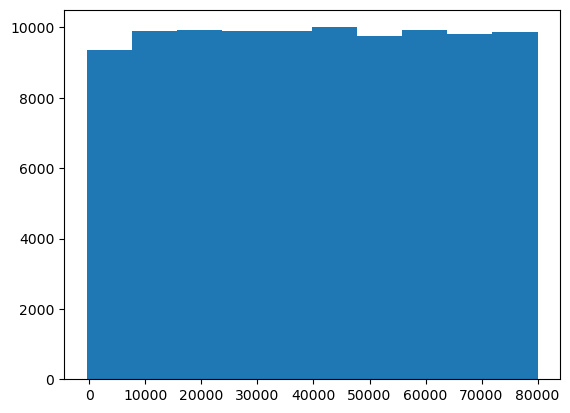

In [77]:
# ploting the amount histogram to see the standard distribution 
plt.hist(df_payment["amount"])
plt.show()

In [78]:
# we can see the data is normally distributed  so we will fill the value

# amount = mean
# payment_method = mode
# payment_status = mode

In [79]:
df_payment["payment_method"] = df_payment["payment_method"].fillna(
    df_payment["payment_method"].mode()[0]
)

In [80]:
df_payment["payment_status"] = df_payment["payment_status"].fillna(df_payment["payment_status"].
    mode()[0])

In [81]:
df_payment["amount"] = df_payment["amount"].fillna(df_payment["amount"].mean())

#### Deal with data cosistent

In [82]:
for i in ("payment_method" , "payment_status"):
    print(i)
    print(df_payment[i].unique())
    print()
    print("-" * 50)

payment_method
['Wallet' 'upi' 'UPI' 'Credit Card' 'COD' 'Debit Card' 'Net Banking'
 'Cash on Delivery']

--------------------------------------------------
payment_status
['Success' 'Failed' 'Refunded' 'Pending' 'success']

--------------------------------------------------


In [83]:
df_payment["payment_method"] = df_payment["payment_method"].str.title()
df_payment["payment_method"] = df_payment["payment_method"].replace({"Cod" : "Cash On Delivery"})
print(df_payment["payment_method"].unique())

['Wallet' 'Upi' 'Credit Card' 'Cash On Delivery' 'Debit Card'
 'Net Banking']


In [84]:
df_payment["payment_status"] = df_payment["payment_status"].str.title()


### Check

In [85]:
df_payment.isnull().sum()

payment_id          0
order_id            0
payment_date      147
payment_method      0
payment_status      0
amount              0
dtype: int64

In [86]:
df_payment.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98354 entries, 1 to 98999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   payment_id      98354 non-null  int64         
 1   order_id        98354 non-null  int64         
 2   payment_date    98207 non-null  datetime64[ns]
 3   payment_method  98354 non-null  object        
 4   payment_status  98354 non-null  object        
 5   amount          98354 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(2)
memory usage: 5.3+ MB


In [87]:
df_payment.dtypes

payment_id                 int64
order_id                   int64
payment_date      datetime64[ns]
payment_method            object
payment_status            object
amount                   float64
dtype: object

In [88]:
df_payment.duplicated().sum()

np.int64(0)

In [89]:
df_payment.describe()

,payment_id,order_id,payment_date,amount
count,98354.000000,98354.000000,98207,98354.000000
mean,749502.028611,550003.765073,2025-11-03 14:36:59.304123136,39930.116412
min,700002.000000,500001.000000,2025-01-01 00:00:00,-500.000000
25%,724760.250000,524990.250000,2025-06-04 00:00:00,19885.762500
50%,749497.500000,550003.500000,2025-11-04 00:00:00,39950.535000
75%,774248.750000,575013.750000,2026-04-06 00:00:00,60005.142500
max,799000.000000,600000.000000,2026-09-05 00:00:00,79999.970000
std,28573.700909,28872.015413,NaN,23116.841462


### Now data are cosistent , no null value , no duplicates , proper data types

### use product table

In [90]:
df_product.head()

,product_id,product_name,category,brand,price,cost_price,stock_qty,supplier
0,1001,UrbanX Product 1001,Accessories,PrimeChoice,3763.91,2069.06,675,Supplier_D
1,1002,HomeEase Product 1002,Home & Kitchen,StyleHub,597.49,468.64,756,Supplier_E
2,1003,StyleHub Product 1003,Electronic,HomeEase,570.82,408.21,632,Supplier_D
3,1004,Nova Product 1004,Home & Kitchen,FitLife,1543.57,870.31,204,Supplier_D
4,1005,TechPro Product 1005,Automotive,Nova,1732.35,867.14,21,Supplier_D


In [91]:
df_product.shape

df_product.columns

Index(['product_id', 'product_name', 'category', 'brand', 'price',
       'cost_price', 'stock_qty', 'supplier'],
      dtype='object')

In [92]:
df_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1000 non-null   int64  
 1   product_name  1000 non-null   object 
 2   category      1000 non-null   object 
 3   brand         1000 non-null   object 
 4   price         965 non-null    float64
 5   cost_price    1000 non-null   float64
 6   stock_qty     1000 non-null   int64  
 7   supplier      1000 non-null   object 
dtypes: float64(2), int64(2), object(4)
memory usage: 62.6+ KB


In [93]:
df_product.isna().sum()

product_id       0
product_name     0
category         0
brand            0
price           35
cost_price       0
stock_qty        0
supplier         0
dtype: int64

In [94]:
df_product.describe()

,product_id,price,cost_price,stock_qty
count,1000.000000,965.000000,1000.000000,1000.000000
mean,1500.500000,12033.374777,1085.115720,473.049000
std,288.819436,101160.680615,932.918455,294.931564
min,1001.000000,-100.000000,53.690000,-5.000000
25%,1250.750000,740.650000,484.200000,215.750000
50%,1500.500000,1279.130000,805.555000,460.500000
75%,1750.250000,2152.000000,1350.595000,722.250000
max,2000.000000,999999.000000,7048.880000,998.000000


In [95]:
for i in ("category" , "brand" , "supplier"):
    print(i)
    print(df_product[i].unique())
    print()
    print("-"* 80)
    

category
['Accessories' 'Home & Kitchen' 'Electronic' 'Automotive' 'Toys' 'Beauty'
 'Books' 'Grocery' 'Sports' 'Electronics' 'Fashion' 'electronics']

--------------------------------------------------------------------------------
brand
['PrimeChoice' 'StyleHub' 'HomeEase' 'FitLife' 'Nova' 'Elite' 'UrbanX'
 'SmartBuy' ' TechPro ' 'TechPro' 'DailyNeeds']

--------------------------------------------------------------------------------
supplier
['Supplier_D' 'Supplier_E' 'Supplier_C' 'Supplier_B' 'Supplier_A']

--------------------------------------------------------------------------------


In [96]:
df_product.duplicated().sum()

np.int64(0)

<h2 align="center">Observation No 5</h2>

### there are 1000 rows and 8 column in this table

### columns are 'product_id', 'product_name', 'category', 'brand', 'price',
### 'cost_price', 'stock_qty', 'supplier

### there is some null value in price column

### there is bit incosistency in category columns

### outliers are present in the price column

### Cleaning

#### Deal with data inconsistency

In [97]:
df_product["category"] = df_product["category"].replace({"Electronic" :
                                                         "Electronics"})
df_product["category"] = df_product["category"].str.strip().str.lower()



In [98]:
df_product["category"].unique()

array(['accessories', 'home & kitchen', 'electronics', 'automotive',
       'toys', 'beauty', 'books', 'grocery', 'sports', 'fashion'],
      dtype=object)

#### Deal with null value

In [99]:
df_product.isnull().sum()

product_id       0
product_name     0
category         0
brand            0
price           35
cost_price       0
stock_qty        0
supplier         0
dtype: int64

####  check for outliers

In [100]:
q1 = df_product["price"].quantile(0.25)
q3 = df_product["price"].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr


print(q1)
print(q3)
print(iqr)
print(lower)
print(upper)

740.65
2152.0
1411.35
-1376.3749999999995
4269.025


In [101]:
df_product = df_product[
    (df_product["price"] >= lower) &
    (df_product["price"] <= upper)
]

In [102]:
df_product.describe()

,product_id,price,cost_price,stock_qty
count,896.000000,896.000000,896.000000,896.000000
mean,1503.476562,1407.093080,912.093237,472.332589
std,290.450579,925.872217,604.606495,294.259178
min,1001.000000,-100.000000,53.690000,-5.000000
25%,1252.500000,706.680000,464.975000,218.750000
50%,1502.500000,1191.245000,758.630000,459.000000
75%,1757.250000,1910.205000,1208.952500,722.000000
max,2000.000000,4245.980000,4079.560000,997.000000


### Now we can say our data is consistent , full filled up 

### Use review table

In [103]:
print(df_review.head())
df_review.shape

   review_id  order_id  customer_id  product_id  rating review_date  \
0     800001    586857       100558        1182       3  2026-05-16   
1     800002    514286       105463        1696       5  2025-09-27   
2     800003    514936       103864        1158       2  2025-07-28   
3     800004    540979       118194        1908       3  2026-03-12   
4     800005    569191       109361        1679       4  2025-12-30   

    review_text  
0  Good product  
1     Excellent  
2     Excellent  
3     Excellent  
4       Average  


(50300, 7)

In [104]:
df_review.isnull().sum()

review_id         0
order_id          0
customer_id       0
product_id        0
rating            0
review_date       0
review_text    4109
dtype: int64

In [105]:
print("duplicate" , df_review.duplicated().sum())
print()
print("-"* 70)
print(df_review.dtypes)


duplicate 300

----------------------------------------------------------------------
review_id       int64
order_id        int64
customer_id     int64
product_id      int64
rating          int64
review_date    object
review_text    object
dtype: object


In [106]:
df_review.describe()

,review_id,order_id,customer_id,product_id,rating
count,50300.000000,50300.000000,50300.000000,50300.000000,50300.000000
mean,824992.468091,550083.076044,111753.184414,3504.745368,3.900378
std,14436.682293,28874.502172,40059.671357,44699.358554,1.149701
min,800001.000000,500003.000000,100001.000000,1001.000000,0.000000
25%,812490.000000,525037.000000,105010.000000,1250.750000,3.000000
50%,824985.500000,550088.500000,110011.000000,1502.000000,4.000000
75%,837494.250000,575087.750000,114995.000000,1751.000000,5.000000
max,850000.000000,599999.000000,999999.000000,999999.000000,6.000000


In [107]:
df_review["review_text"].unique()

array(['Good product', 'Excellent', 'Average', 'Not satisfied', nan,
       'Very poor'], dtype=object)

<h2 align="center">Observation No 6</h2>

#### 1 . There are 50300 row and 7columns

#### 2 . All datatypes are perfect except date

#### 3 . there is 4109 null value present in review text

#### 4 . data is consistent


### Cleaning process

In [108]:
df_review.dtypes
# deal with datatype

review_id       int64
order_id        int64
customer_id     int64
product_id      int64
rating          int64
review_date    object
review_text    object
dtype: object

In [109]:
df_review["review_date"] = pd.to_datetime(df_review["review_date"])

In [110]:
# deal with duplicate value

df_review.duplicated().sum()

np.int64(300)

In [111]:
df_review[df_review.duplicated()]

,review_id,order_id,customer_id,product_id,rating,review_date,review_text
50000,816478,549175,107527,1719,3,2025-02-27,Good product
50001,805970,572545,103663,1127,4,2026-02-25,NaN
50002,846460,578078,106213,1543,5,2026-05-06,Not satisfied
50003,833298,587060,102041,1537,5,2025-03-30,Good product
50004,835048,556154,104154,1651,2,2025-04-19,Not satisfied
...,...,...,...,...,...,...,...
50295,800394,538685,108711,1679,5,2025-09-22,Good product
50296,834436,500510,104577,1530,4,2026-02-16,Excellent
50297,837013,574423,106828,1219,4,2026-06-16,Excellent
50298,803467,525037,117779,1599,5,2026-06-26,Not satisfied


In [112]:
df_review = df_review.drop_duplicates()

In [113]:
df_review.isna().sum()

review_id         0
order_id          0
customer_id       0
product_id        0
rating            0
review_date       0
review_text    4085
dtype: int64

In [114]:
# since its review text so we cant directly put any value so we will fill up with not provided

df_review["review_text"] = df_review["review_text"].fillna("not Provided")

### Check

In [115]:
df_review.isna().sum()

review_id      0
order_id       0
customer_id    0
product_id     0
rating         0
review_date    0
review_text    0
dtype: int64

In [116]:
df_review.duplicated().sum()

np.int64(0)

In [117]:
df_review.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   review_id    50000 non-null  int64         
 1   order_id     50000 non-null  int64         
 2   customer_id  50000 non-null  int64         
 3   product_id   50000 non-null  int64         
 4   rating       50000 non-null  int64         
 5   review_date  50000 non-null  datetime64[ns]
 6   review_text  50000 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 3.1+ MB


### Now we can say our data is consistent and having no any miss value or any duplicate value

In [118]:
final_df = (
    df_order
    .merge(df_customer, on="customer_id", how="left")
    .merge(df_order_item, on="order_id", how="left")
    .merge(df_product, on="product_id", how="left")
    .merge(df_payment, on="order_id", how="left")
    .merge(
        df_review,
        on=["order_id", "customer_id", "product_id"],
        how="left"
    )
)

In [119]:
final_df.head()

,order_id,customer_id,order_date,shipping_city,shipping_state,order_status,coupon_code,discount_pct,delivery_days,customer_name,gender,age,city,state,signup_date,customer_segment,order_item_id,product_id,quantity,product_name,category,brand,price,cost_price,stock_qty,supplier,payment_id,payment_date,payment_method,payment_status,amount,review_id,rating,review_date,review_text
0,500001,106643,2025-03-10,Jaipur,Maharashtra,Delivered,NONE,20,6,Anjali Das,Male,54.000000,Delhi,Delhi,2024-12-16,New,900001,1241,2,PrimeChoice Product 1241,fashion,SmartBuy,667.00,498.23,692.0,Supplier_E,791583.0,2026-01-18,Cash On Delivery,Success,11088.10,NaN,NaN,NaT,NaN
1,500002,108613,2025-01-23,Chandigarh,Madhya Pradesh,Delivered,NONE,15,7,Priya Sinha,Male,45.000000,Kanpur,Uttar Pradesh,2023-08-04,Premium,900002,1733,3,Nova Product 1733,books,SmartBuy,802.71,563.96,608.0,Supplier_E,787723.0,2026-04-18,Cash On Delivery,Success,37026.52,NaN,NaN,NaT,NaN
2,500003,112887,2025-12-23,Kanpur,Maharashtra,Shipped,FLASH15,30,7,Kavita Malhotra,Female,38.000000,Surat,Gujarat,2025-01-02,Regular,900003,1444,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,795935.0,2025-12-20,Upi,Success,56481.69,NaN,NaN,NaT,NaN
3,500004,100810,2025-04-21,Jaipur,Maharashtra,Delivered,NEWUSER,0,3,Priya Mehta,Female,43.484977,Lucknow,Uttar Pradesh,2024-10-19,New,900004,1852,1,StyleHub Product 1852,electronics,SmartBuy,3465.58,1760.93,805.0,Supplier_E,740909.0,2025-03-11,Debit Card,Success,53979.05,NaN,NaN,NaT,NaN
4,500004,100810,2025-04-21,Jaipur,Maharashtra,Delivered,NEWUSER,0,3,Priya Mehta,Female,43.484977,Lucknow,Uttar Pradesh,2024-10-19,New,900005,1561,3,FitLife Product 1561,electronics,PrimeChoice,463.80,356.05,468.0,Supplier_A,740909.0,2025-03-11,Debit Card,Success,53979.05,NaN,NaN,NaT,NaN


In [120]:
final_df["year"] = final_df["payment_date"].dt.year

In [121]:
final_df["month"] = final_df["payment_date"].dt.month

In [122]:
final_df["month"].dtypes

dtype('float64')

In [123]:
final_df["month"] = final_df["month"].astype("int64", errors="ignore")

### Univariate Analysis

### 1. Numerical columns

In [124]:
num_col = final_df.select_dtypes(include = "number").columns

In [125]:
num_col

Index(['order_id', 'customer_id', 'discount_pct', 'delivery_days', 'age',
       'order_item_id', 'product_id', 'quantity', 'price', 'cost_price',
       'stock_qty', 'payment_id', 'amount', 'review_id', 'rating', 'year',
       'month'],
      dtype='object')

#### A. Statistical summary

In [126]:
final_df.describe()

,order_id,customer_id,order_date,discount_pct,delivery_days,age,signup_date,order_item_id,product_id,quantity,price,cost_price,stock_qty,payment_id,payment_date,amount,review_id,rating,review_date,year,month
count,155023.000000,155023.000000,155023,155023.000000,155023.000000,154275.000000,154275,1.550230e+05,155023.000000,155023.000000,138672.000000,138672.000000,138672.000000,152436.000000,152206,152436.000000,0.0,0.0,0,152206.000000,152206.000000
mean,550045.587519,113752.910904,2025-10-31 03:09:24.651696640,9.471466,3.950549,43.475146,2023-07-08 09:59:58.179873280,9.775120e+05,3432.364868,1.940589,1410.388877,914.029854,473.014141,749508.930554,2025-11-03 17:46:30.812451328,39936.413743,NaN,NaN,NaT,2025.406594,5.754228
min,500001.000000,100001.000000,2025-01-01 00:00:00,0.000000,-3.000000,3.000000,2021-01-01 00:00:00,9.000010e+05,1001.000000,-2.000000,-100.000000,53.690000,-5.000000,700002.000000,2025-01-01 00:00:00,-500.000000,NaN,NaN,NaT,2025.000000,1.000000
25%,525054.500000,104973.000000,2025-06-02 00:00:00,0.000000,2.000000,31.000000,2022-04-03 00:00:00,9.387565e+05,1251.000000,1.000000,709.360000,468.640000,219.000000,724863.000000,2025-06-03 00:00:00,19917.790000,NaN,NaN,NaT,2025.000000,3.000000
50%,550056.000000,110062.000000,2025-10-31 00:00:00,10.000000,3.000000,43.484977,2023-07-16 00:00:00,9.775120e+05,1502.000000,2.000000,1195.180000,758.870000,460.000000,749450.500000,2025-11-05 00:00:00,39987.870000,NaN,NaN,NaT,2025.000000,6.000000
75%,575071.500000,115093.000000,2026-04-01 00:00:00,15.000000,5.000000,56.000000,2024-10-09 00:00:00,1.016268e+06,1751.000000,2.000000,1911.660000,1209.380000,722.000000,774187.250000,2026-04-06 00:00:00,59962.330000,NaN,NaN,NaT,2026.000000,8.000000
max,600000.000000,999999.000000,2026-08-31 00:00:00,150.000000,15.000000,120.000000,2025-12-31 00:00:00,1.055023e+06,999999.000000,10.000000,4245.980000,4079.560000,997.000000,799000.000000,2026-09-05 00:00:00,79999.970000,NaN,NaN,NaT,2026.000000,12.000000
std,28884.398592,54720.168194,NaN,12.095107,2.472150,15.308746,NaN,4.475143e+04,43883.404407,1.347396,926.401308,606.164315,294.125815,28528.122278,NaN,23083.994251,NaN,NaN,NaN,0.491199,3.197094


#### B. Distribution — Histogram

Text(0.5, 1.0, 'cost_price_distribution')

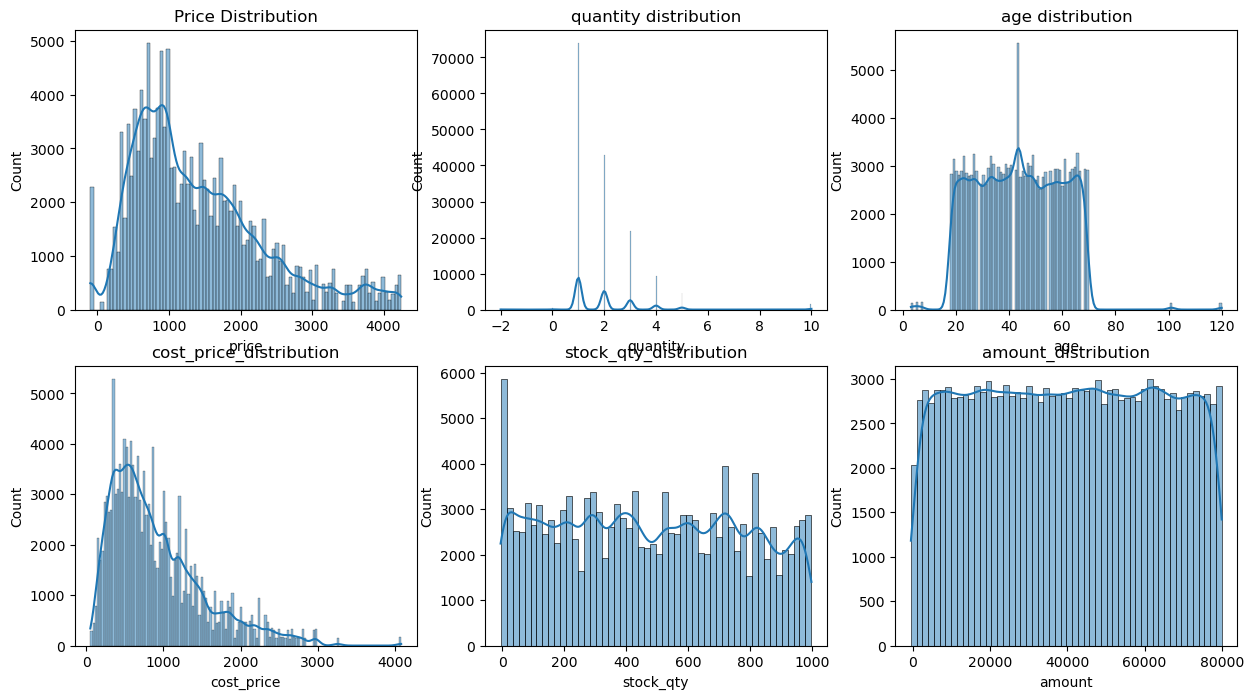

In [127]:

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(data=final_df, x="price",kde = True, ax=axes[0, 0]).set_title("Price Distribution")
print()
sns.histplot(data = final_df, x = "quantity",kde = True , ax = axes [0 ,1] ).set_title("quantity distribution")
sns.histplot(data= final_df, x = "age", kde = True , ax = axes[ 0,2]).set_title("age distribution")
sns.histplot(data = final_df, kde = True , x = "amount" , ax = axes[1,2]).set_title("amount_distribution")
sns.histplot(data = final_df,kde = True,  x = "stock_qty" , ax = axes[1,1]).set_title("stock_qty_distribution")
sns.histplot(data = final_df ,kde = True,  x = "cost_price" , ax = axes[1,0]).set_title("cost_price_distribution")

#### C. Outlier — Boxplot

Text(0.5, 1.0, 'cost_price_distribution')

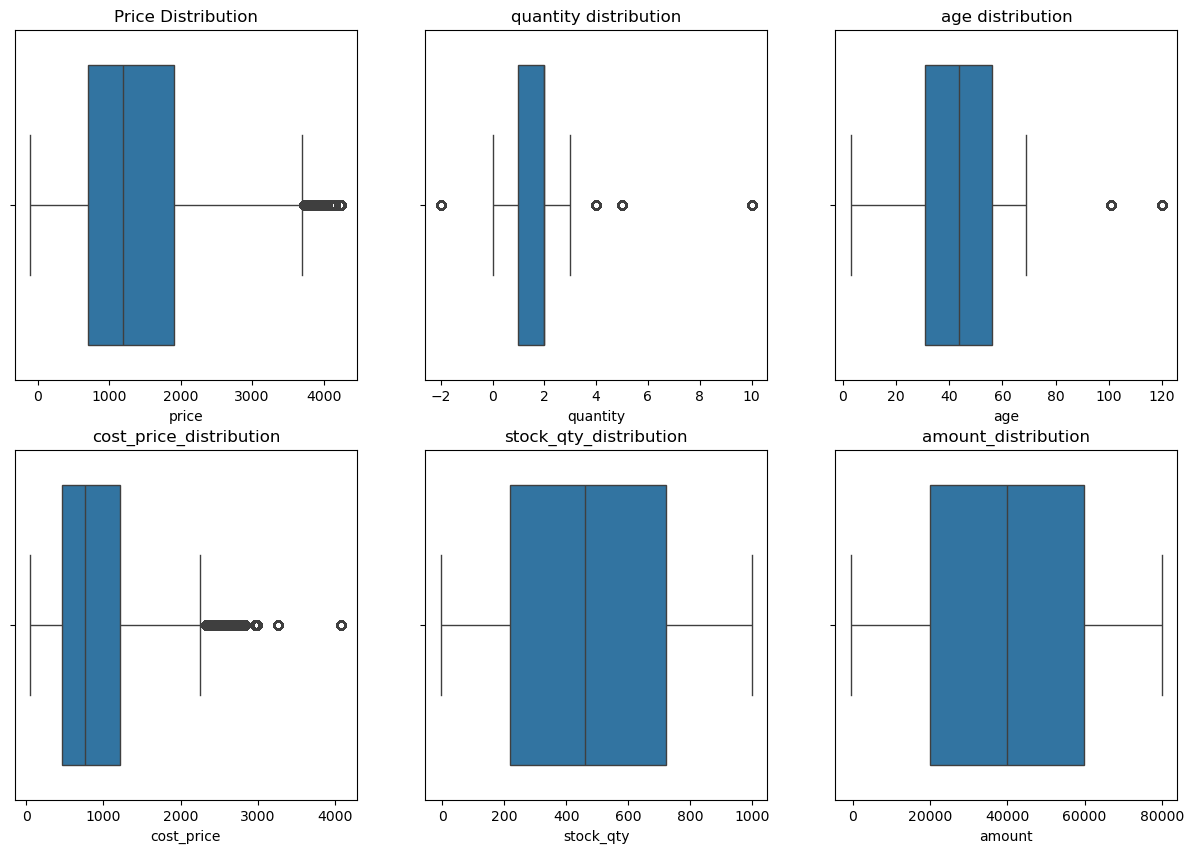

In [128]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.boxplot(data=final_df, x="price", ax=axes[0, 0]).set_title("Price Distribution")
print()
sns.boxplot(data = final_df, x = "quantity" , ax = axes [0 ,1] ).set_title("quantity distribution")
sns.boxplot(data= final_df, x = "age" , ax = axes[ 0,2]).set_title("age distribution")
sns.boxplot(data = final_df , x = "amount" , ax = axes[1,2]).set_title("amount_distribution")
sns.boxplot(data = final_df, x = "stock_qty" , ax = axes[1,1]).set_title("stock_qty_distribution")
sns.boxplot(data = final_df , x = "cost_price" , ax = axes[1,0]).set_title("cost_price_distribution")

###  Insight 
#### "The boxplot analysis shows that price and cost_price are highly right-skewed and contain several high-value outliers. Quantity contains both negative and unusually high values, which may indicate data-quality issues. Age has a few extreme observations above 100 that should be validated. In contrast, stock_qty and amount do not show significant outlier observations."

### Remove outlier

In [129]:
# Apply business-rule validation for clearly invalid values.
# Statistical outliers are reviewed separately rather than automatically deleted.

final_df = final_df[final_df["quantity"] > 0]
final_df = final_df[final_df["price"] >= 0]
final_df = final_df[final_df["cost_price"] >= 0]
final_df = final_df[final_df["discount_pct"].between(0, 100)]
final_df = final_df[final_df["age"].between(18, 100)]

final_df = final_df.reset_index(drop=True)

print("Rows after business-rule validation:", len(final_df))


Rows after business-rule validation: 134019


#### check

Text(0.5, 1.0, 'cost_price_distribution')

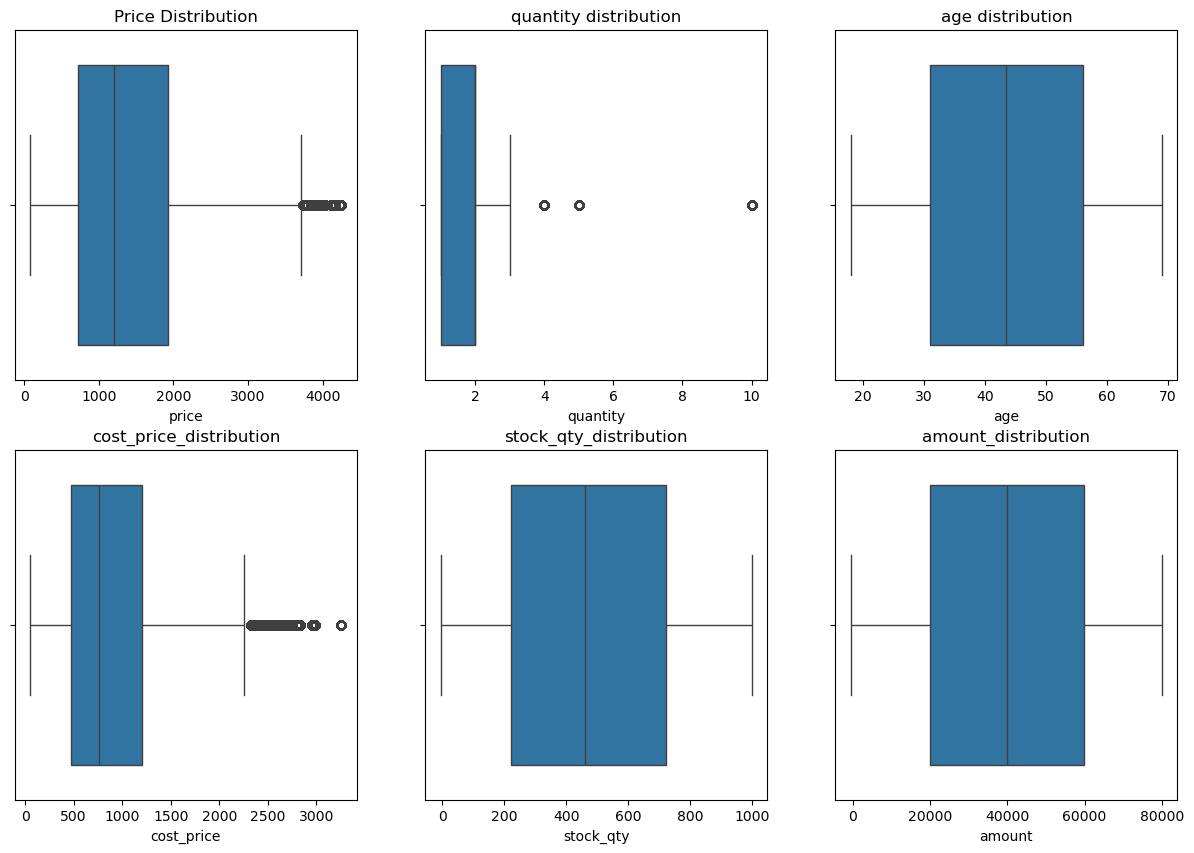

In [130]:

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

sns.boxplot(data=final_df, x="price", ax=axes[0, 0]).set_title("Price Distribution")

sns.boxplot(data = final_df, x = "quantity" , ax = axes [0 ,1] ).set_title("quantity distribution")
sns.boxplot(data= final_df, x = "age" , ax = axes[ 0,2]).set_title("age distribution")
sns.boxplot(data = final_df , x = "amount" , ax = axes[1,2]).set_title("amount_distribution")
sns.boxplot(data = final_df, x = "stock_qty" , ax = axes[1,1]).set_title("stock_qty_distribution")
sns.boxplot(data = final_df , x = "cost_price" , ax = axes[1,0]).set_title("cost_price_distribution")

### Outlier Treatment

Extreme observations were reviewed using statistical methods and business rules.
Clearly invalid values were handled before the final analysis, while genuine
high-value transactions were not automatically removed only because they were
statistical outliers.


### 2. Categorical columns


In [131]:
cat_columns = final_df.select_dtypes(include = "object").columns

In [132]:
cat_columns

Index(['shipping_city', 'shipping_state', 'order_status', 'coupon_code',
       'customer_name', 'gender', 'city', 'state', 'customer_segment',
       'product_name', 'category', 'brand', 'supplier', 'payment_method',
       'payment_status', 'review_text'],
      dtype='object')

### countplot of important data

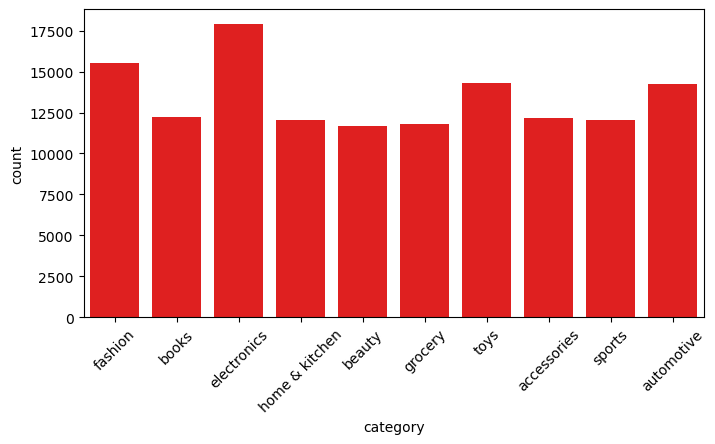

In [133]:
# category columns countplot

plt.figure(figsize=(8, 4))
sns.countplot(data = final_df , x = "category" ,  color = "red")
plt.xticks(rotation = 45)
plt.show()


### Insight

Fashion contributes the largest share of records, while Electronics represents
a smaller share compared with the highest-volume categories. The category
distribution is relatively balanced across most categories.


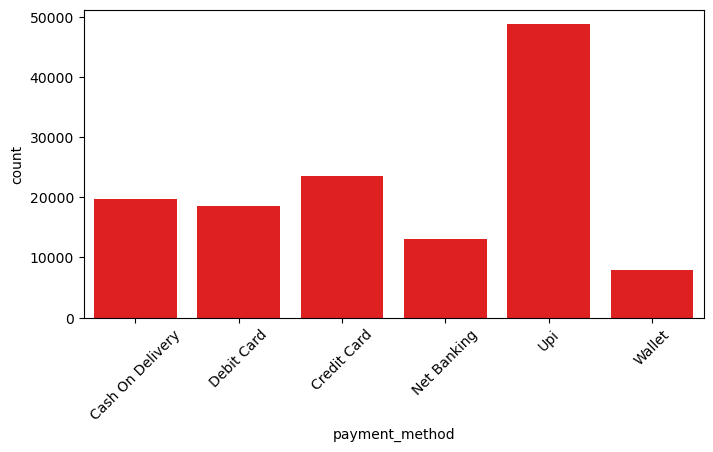

In [134]:
# payment method countplot

plt.figure(figsize=(8, 4))
sns.countplot(data = final_df , x = 'payment_method' , color = "red")
plt.xticks(rotation = 45)
plt.show()


### Insight
#### "UPI is the most frequently used payment method, while Cash on Delivery has the lowest transaction count. Card-based payments form the second-largest group. The presence of both 'COD' and 'Cash on Delivery' suggests a possible category-standardization issue that should be addressed during data cleaning.

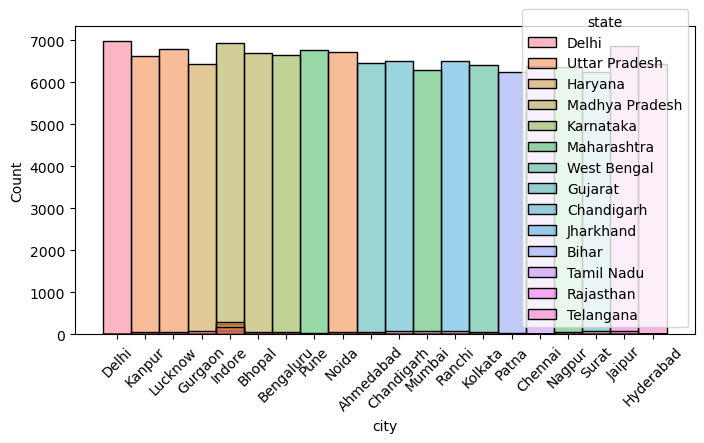

In [135]:
# city and state countplot
plt.figure(figsize=(8, 4))
sns.histplot(data = final_df , x = "city" , hue = "state")
plt.xticks(rotation = 45)
plt.show()



### Insight 
#### "The city-wise distribution is relatively balanced, with most cities having approximately 5,500–6,000 records. Delhi and Indore have comparatively higher counts, while Patna has a relatively lower count. No major imbalance is observed across cities."


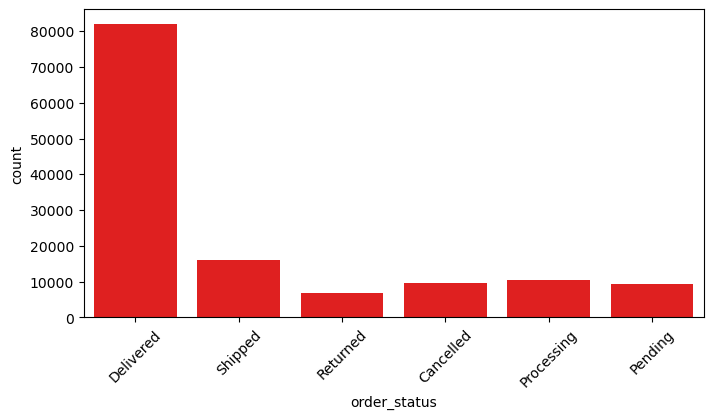

In [136]:
plt.figure(figsize=(8, 4))
sns.countplot(data = final_df , x = 'order_status' , color = "red")
plt.xticks(rotation = 45)
plt.show()


### Insight
#### "The order-status analysis shows that Delivered orders dominate the dataset, followed by Shipped orders. Processing, Pending, and Canceled orders occur at moderate levels, while Returned orders have the lowest count. This indicates that most recorded orders have reached the delivered stage."

### Bivariate Analysis

#### Numerical vs Numberical

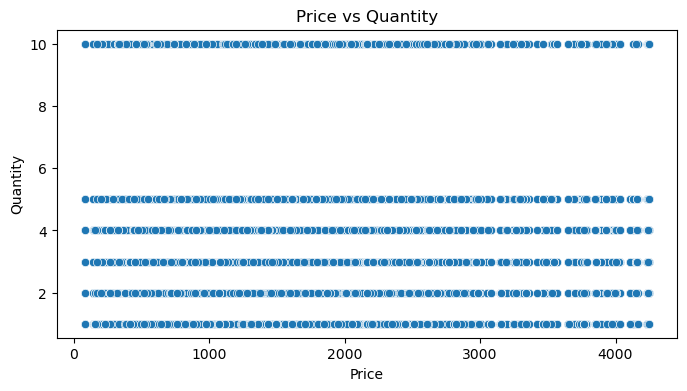

In [137]:
# price vs quantity scatterplot

plt.figure(figsize = ( 8 , 4))
sns.scatterplot(data = final_df , x = "price" , y = "quantity")
plt.title("Price vs Quantity")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.show()


### Insight
#### "The scatter plot does not show a clear relationship between price and quantity. Quantity is concentrated at discrete values of 0–3, while price varies widely across all quantity levels. Therefore, price alone does not appear to strongly determine the quantity in this dataset. Some zero-quantity and potentially negative-price observations should also be validated."

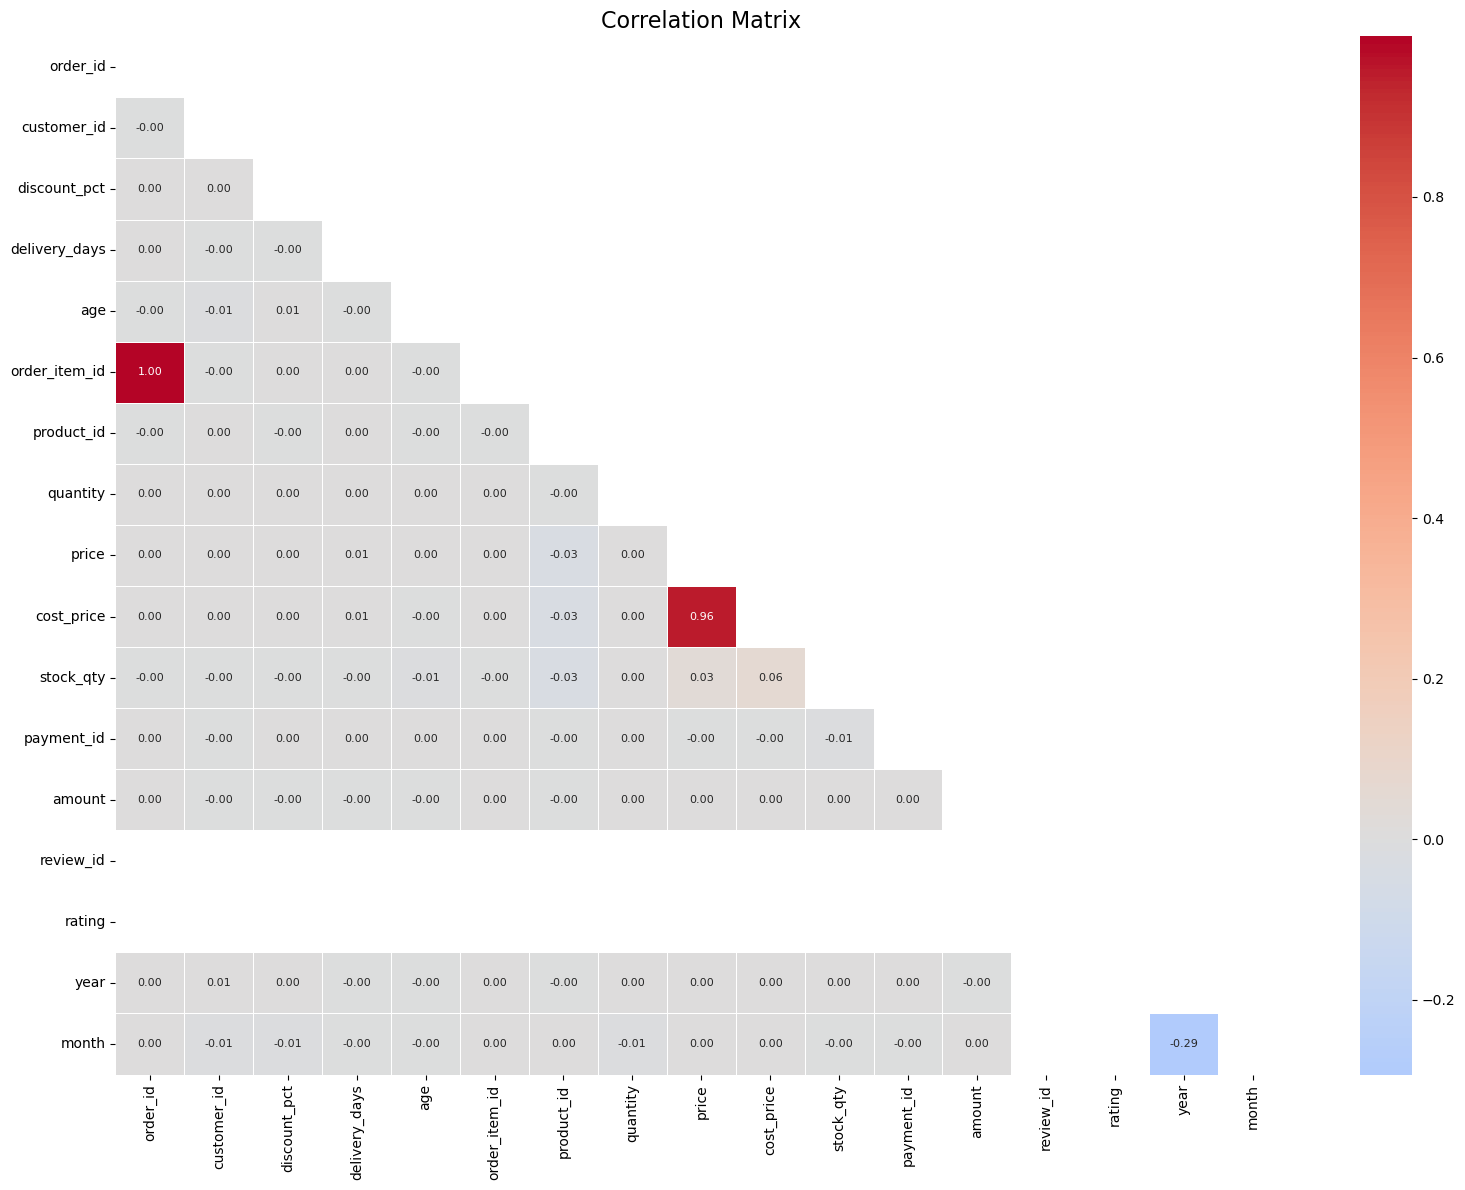

In [138]:
# 2. correlation between price and quantity
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr = final_df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    center=0,
    annot_kws={"size": 8}
)

plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

### Insight 
#### "The correlation analysis shows a strong positive correlation of approximately 0.91 between price and cost price, indicating that higher-cost products generally have higher selling prices. Most other numerical variables show weak or negligible linear correlations. Identifier columns such as order_id and product_id should not be interpreted as meaningful business relationships."

#### 2 - Categorical vs numberical

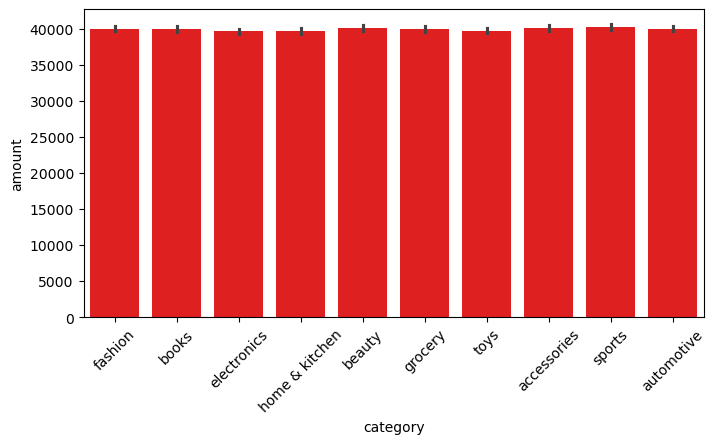

In [139]:
 # 1 — Category vs Revenue/Amount
plt.figure(figsize = ( 8 , 4))
sns.barplot(data = final_df , x = "category" , y = "amount" , color = "Red")
plt.xticks(rotation = 45)
plt.show()

### Insight 
#### "The average transaction amount is relatively consistent across all product categories, remaining close to ₹40,000. Sports and Automotive show slightly higher average amounts, while some categories are marginally lower. Overall, there is no major difference in average transaction value across categories."

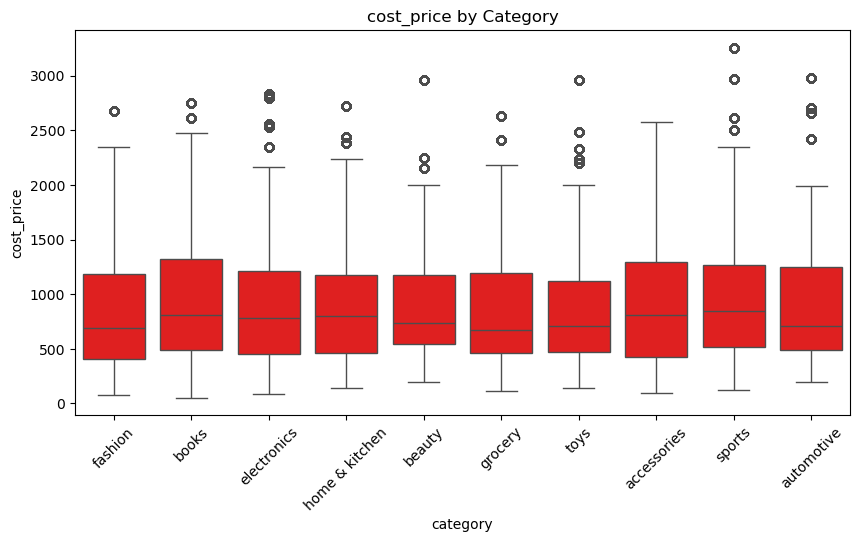

In [140]:
# Step 2 — Category vs cost price

plt.figure(figsize=(10, 5))

sns.boxplot(
    data=final_df,
    x="category",
    y="cost_price",
    color = "red")

plt.title("cost_price by Category")
plt.xticks(rotation=45)
plt.show()



### Insight

Category-wise cost prices show differences in their distributions and median
values. Higher-value categories tend to have higher median cost prices, while
the distributions still show variation within individual categories.


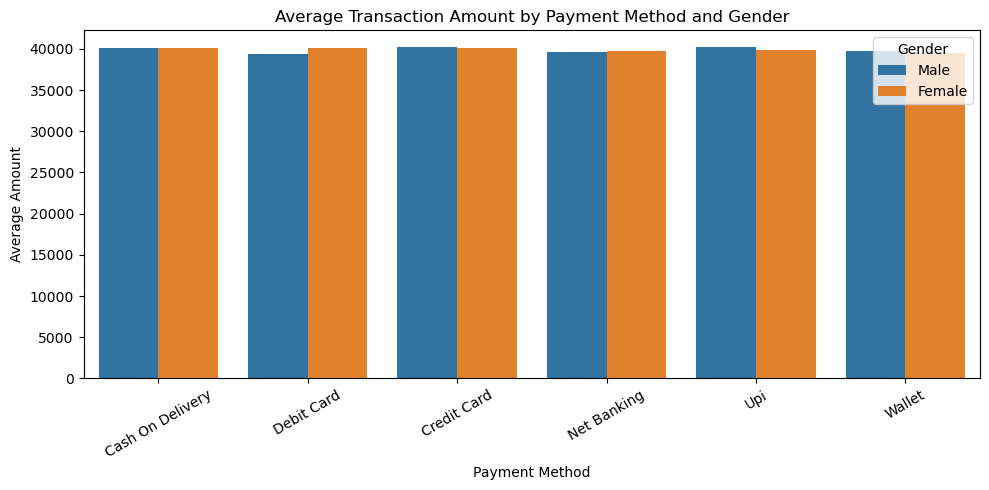

In [141]:
# step 4 - gender & payment_method vs amount
plt.figure(figsize=(10 , 5 ))

sns.barplot(
    data=final_df,
    x="payment_method",
    y="amount",
    hue="gender",
    errorbar=None
)

plt.title("Average Transaction Amount by Payment Method and Gender")
plt.xlabel("Payment Method")
plt.ylabel("Average Amount")
plt.xticks(rotation=30)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

### Insight 
#### "The analysis shows that average transaction amounts are fairly consistent between male and female customers across different payment methods. Most payment methods have average transaction values close to ₹40,000, with only minor gender-based differences. Cash on Delivery shows a comparatively lower average transaction amount."

In [142]:
# creating a profit table

final_df["profit"] = (
    final_df["price"] - final_df["cost_price"]
) * final_df["quantity"]

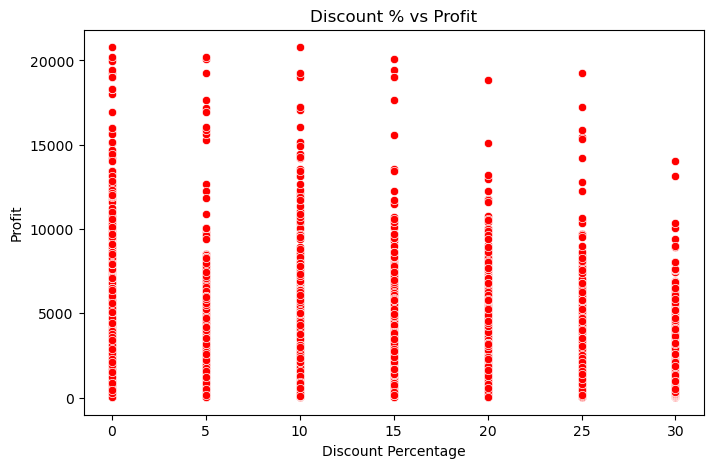

In [143]:
# plotting scatterplot between discount % and profit

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=final_df,
    x= "discount_pct",
    y= "profit",
    color = "red"
)

plt.title("Discount % vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")

plt.show()

### Insight 
#### The scatter plot shows that profit varies widely at each discount level. Higher discount percentages are associated with a lower upper range of profit, suggesting a possible negative relationship between discount and profit. However, substantial variation exists at every discount level, so correlation or statistical testing would be required to quantify this relationship."

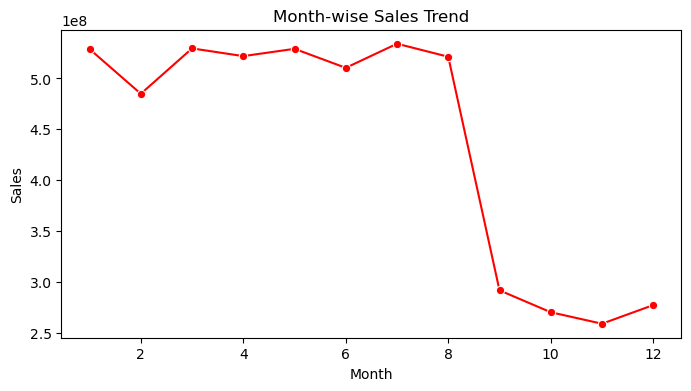

In [144]:
# year wise sales
monthly_sales = final_df.groupby("month")["amount"].sum().reset_index()

plt.figure(figsize=(8, 4))

sns.lineplot(data=monthly_sales, x="month", y="amount", marker="o", color = "red")

plt.xlabel("Month")
plt.title("Month-wise Sales Trend")
plt.ylabel("Sales")

plt.show()



### Insight

Sales show variation across months, with differences between earlier and later
months. The reason for this pattern would require further investigation using
additional business or seasonal information.


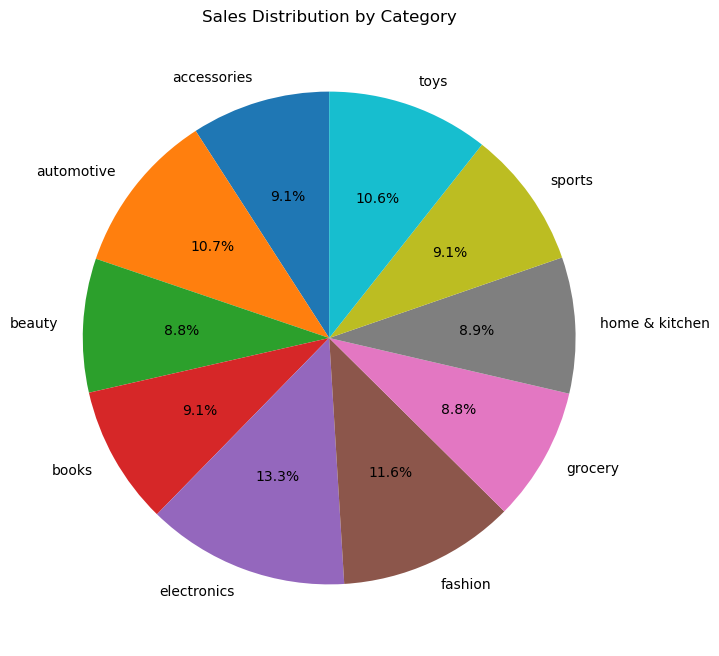

In [145]:
# categorywise total sell

category_sales = final_df.groupby("category")["amount"].sum()

plt.figure(figsize=(8, 8))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales Distribution by Category")
plt.show()

### Insight

Fashion contributes the largest share of total sales among the analyzed
categories. Sales are distributed across multiple categories rather than being
concentrated in a single category.


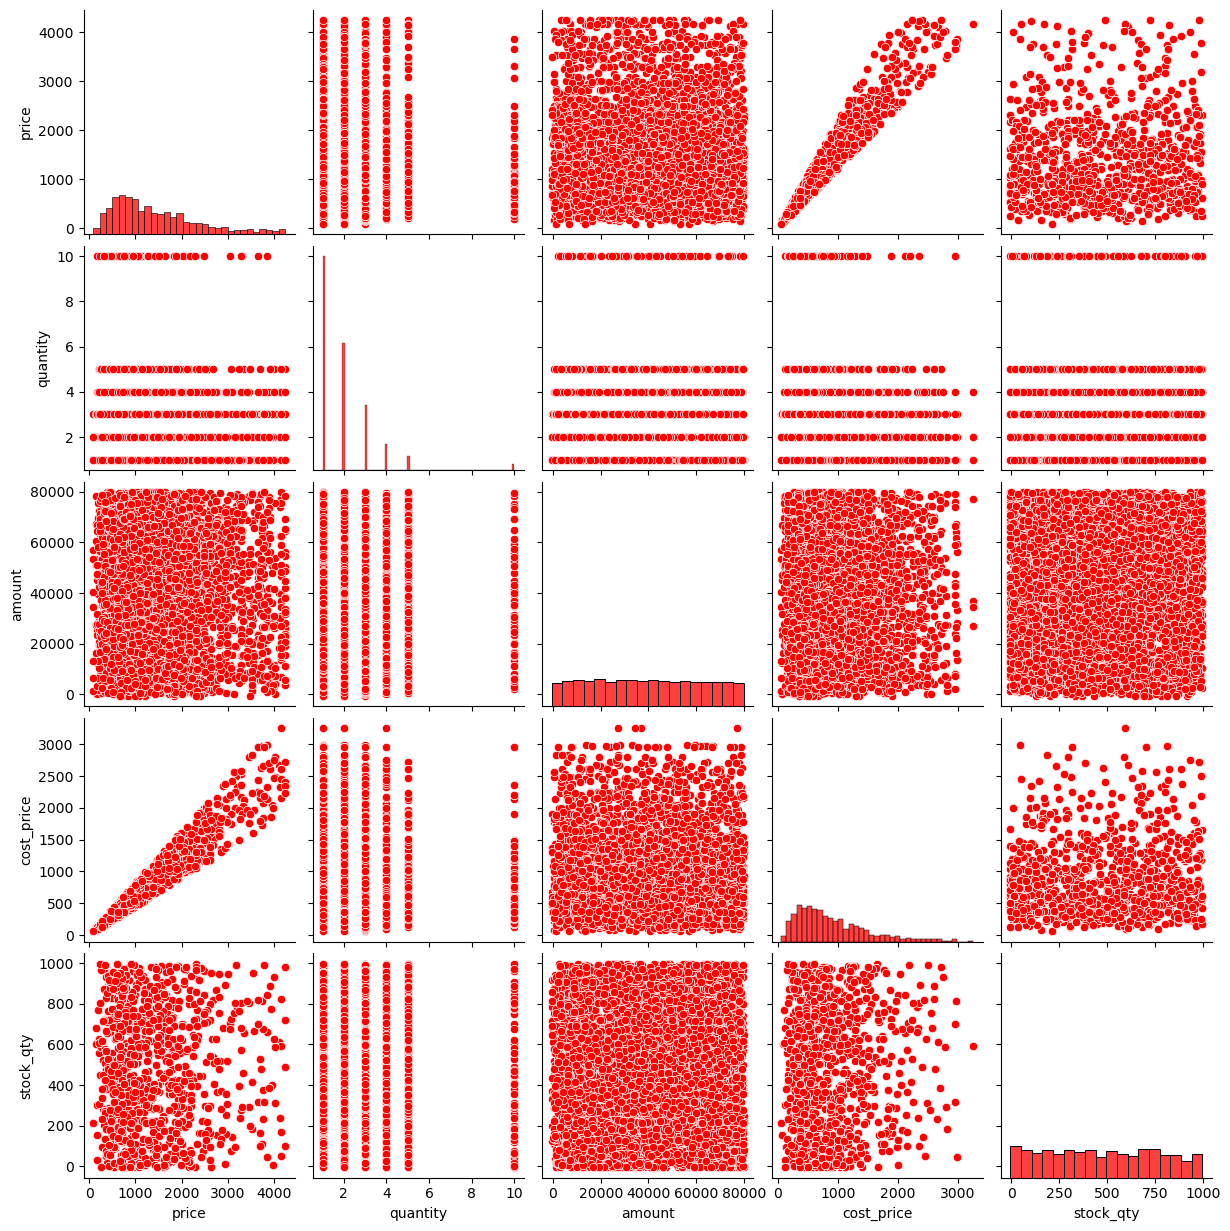

In [146]:
cols = ["price", "quantity", "amount", "cost_price", "stock_qty"]

sns.pairplot(
    final_df[cols].sample(5000, random_state=42),
    diag_kind="hist",
    plot_kws={"color": "red"},
    diag_kws={"color": "red"}
)

plt.show()

### Insight

#### "The pairplot reveals a strong positive relationship between price and cost_price, which is consistent with the correlation analysis. Other numerical variables show relatively scattered patterns with no strong visible linear relationships. Quantity is concentrated at discrete values, while price and cost_price show right-skewed distributions."

In [147]:
# creating some columns 
final_df.columns
final_df["gross_amount"] = final_df["quantity"] * final_df["price"]

final_df["discount_amount"] = (
    final_df["gross_amount"] * final_df["discount_pct"] / 100
)

final_df["net_amount"] = (
    final_df["gross_amount"] - final_df["discount_amount"]
)

final_df["profit"] = (
    final_df["net_amount"] -
    (final_df["cost_price"] * final_df["quantity"])
)

final_df["profit_margin"] = (
    final_df["profit"] / final_df["net_amount"] * 100)

In [148]:
final_df.columns

Index(['order_id', 'customer_id', 'order_date', 'shipping_city',
       'shipping_state', 'order_status', 'coupon_code', 'discount_pct',
       'delivery_days', 'customer_name', 'gender', 'age', 'city', 'state',
       'signup_date', 'customer_segment', 'order_item_id', 'product_id',
       'quantity', 'product_name', 'category', 'brand', 'price', 'cost_price',
       'stock_qty', 'supplier', 'payment_id', 'payment_date', 'payment_method',
       'payment_status', 'amount', 'review_id', 'rating', 'review_date',
       'review_text', 'year', 'month', 'profit', 'gross_amount',
       'discount_amount', 'net_amount', 'profit_margin'],
      dtype='object')

### Business Questions

### 1 . Using final_df, perform a category-wise analysis.
Calculate for each category:
Total Revenue ,
Total Profit,
Average Discount %


In [149]:
final_df.groupby("category").agg(
    total_revenue=("net_amount", "sum"),
    total_profit=("profit", "sum"),
    average_discount=("discount_pct", "mean")
).sort_values("total_revenue", ascending=False)

,total_revenue,total_profit,average_discount
category,,,
electronics,4.768028e+07,1.488876e+07,9.008873
fashion,3.747184e+07,1.121540e+07,8.978526
automotive,3.695909e+07,1.169044e+07,9.053978
toys,3.577275e+07,1.165204e+07,9.083537
books,3.329935e+07,1.040830e+07,9.082993
sports,3.245189e+07,9.158512e+06,9.185197
accessories,3.170517e+07,9.558319e+06,8.950136
grocery,2.923992e+07,8.739706e+06,9.006432
home & kitchen,2.906476e+07,8.198791e+06,9.035029


#### Using final_df, find the top 5 products in each category based on total profit.

In [150]:
result = final_df.groupby(["category", "product_name"]).agg(
    total_profit=("profit", "sum")
).reset_index()

result["rank"] = result.groupby("category")["total_profit"].rank(
    method="dense",
    ascending=False
)

top_5_products = result[result["rank"] <= 5]

top_5_products = top_5_products.sort_values(
    ["category", "total_profit"],
    ascending=[True, False]
)

top_5_products


,category,product_name,total_profit,rank
42,accessories,PrimeChoice Product 1687,436664.1675,1.0
18,accessories,FitLife Product 1950,429441.5020,2.0
61,accessories,TechPro Product 1012,404503.1280,3.0
71,accessories,UrbanX Product 1001,403797.5825,4.0
3,accessories,Elite Product 1039,393803.7040,5.0
86,automotive,DailyNeeds Product 1521,460668.4075,1.0
150,automotive,TechPro Product 1026,442829.2560,2.0
113,automotive,HomeEase Product 1828,352838.6870,3.0
91,automotive,Elite Product 1187,320258.1720,4.0
134,automotive,SmartBuy Product 1028,297795.5700,5.0


### Using final_df, find the average price of products for each category.
### Then:
### Calculate average_price
### Keep only categories where average_price > 2000
### Sort by average_price in descending order

In [151]:
result = final_df.groupby("category").agg(
    average_price=("price", "mean")
).reset_index()


result = result.sort_values(
    "average_price",
    ascending=False
)

result


,category,average_price
3,books,1523.115201
4,electronics,1500.791745
8,sports,1492.076240
1,automotive,1464.695542
0,accessories,1456.420409
9,toys,1408.574668
2,beauty,1384.498917
7,home & kitchen,1373.279607
6,grocery,1371.412554
5,fashion,1368.226658


#### Using final_df, calculate the average order value (AOV) for each city.
Requirements:
Group by city
Calculate:
total_orders
average_order_value based on amount
Keep only cities with at least 100 orders
Sort by average_order_value in descending order

In [152]:
result = final_df.groupby("city").agg(
    total_orders=("order_id", "nunique"),
    average_order_value=("amount", "mean")
).reset_index()

result = result[result["total_orders"] >= 100]

result = result.sort_values(
    "average_order_value",
    ascending=False
)

result

,city,total_orders,average_order_value
7,Hyderabad,4386,40549.022991
6,Gurgaon,4471,40386.741511
16,Patna,4315,40345.652515
4,Chennai,4388,40269.291951
12,Lucknow,4704,40183.082893
9,Jaipur,4733,40096.219033
5,Delhi,4753,40090.289574
14,Nagpur,4401,40057.915881
8,Indore,5857,40053.437937
13,Mumbai,4343,40013.863602


#### Find the top 5 categories by total sales amount.

    

In [153]:
final_df.groupby("category")["net_amount"] \
    .sum() \
    .sort_values(ascending=False) \
    .head(5)

category
electronics    4.768028e+07
fashion        3.747184e+07
automotive     3.695909e+07
toys           3.577275e+07
books          3.329935e+07
Name: net_amount, dtype: float64

#### Compare the average price and cost_price for each category.

In [154]:
final_df.groupby("category").agg(
    avg_price=("price", "mean"),
    avg_cost_price=("cost_price", "mean")
)

,avg_price,avg_cost_price
category,,
accessories,1456.420409,927.324687
automotive,1464.695542,909.877499
beauty,1384.498917,887.045102
books,1523.115201,953.448603
electronics,1500.791745,937.286501
fashion,1368.226658,871.344944
grocery,1371.412554,875.371158
home & kitchen,1373.279607,896.289598
sports,1492.076240,972.681479


 <h2 align="center">EXECUTIVE SUMMARY</h2>

#### This project focuses on performing an end-to-end E-Commerce Sales Analytics and Exploratory Data Analysis (EDA) using multiple interconnected datasets such as Customers, Products, Orders, Order Items, Payments, and Reviews.

#### The project involved understanding the raw data, identifying data-quality issues, cleaning and standardizing the datasets, combining multiple tables using appropriate keys, and creating business-oriented features such as Gross Amount, Discount Amount, Net Amount, Profit, and Profit Margin.

#### After data preparation, exploratory analysis was performed to understand sales performance, profitability, customer behavior, product categories, discounts, and relationships between numerical variables.

#### The analysis helps convert raw transactional data into meaningful business insights that can support decisions related to product performance, pricing, discounts, profitability, and customer analysis.


<h2 align="center">KEY BUSINESS INSIGHT</h2>

### 1. Category Performance
#### Electronics generated the highest net revenue among the analyzed categories.
#### Automotive generated a strong profit contribution.
#### Different categories show differences between revenue and profitability, indicating that high sales volume does not necessarily mean the same level of profit.

### 2. Pricing & Cost
#### The pairplot indicates a strong positive relationship between product price and cost price.
#### This suggests that products with higher selling prices generally also have higher underlying costs.
#### Price and cost-price distributions show right-skewness, indicating the presence of relatively high-value products.
### 3. Quantity
#### Quantity values are concentrated around discrete values rather than being continuously distributed.
#### This is expected in transactional order data because customers generally purchase whole units.
### 4. Discount
#### Average category-level discounts are relatively close to each other, generally around the 9–10% range in the analyzed data.
#### Therefore, differences in profitability cannot be explained by discount percentage alone; product price, cost, quantity, and category performance also matter.
### 5. Data Quality
#### The project identified several real-world data-quality problems, including:
#### Missing values
#### Duplicate records
#### Inconsistent categorical values
#### Invalid/negative numerical values
#### Data-type issues
#### Invalid foreign-key relationships
### 6. Outliers
#### Inconsistent payment/category values
#### This makes the project more realistic than simply performing analysis on already-clean data.


<h2 align="center">FINAL CONCLUSION</h2>

#### The E-Commerce Analytics project demonstrates the complete workflow of converting raw, imperfect transactional data into meaningful business insights.
#### The analysis started with data understanding and quality assessment, followed by cleaning of individual tables and handling issues such as missing values, duplicates, inconsistent categorical values, incorrect data types, and unusual numerical observations.
#### After cleaning, the datasets were integrated using their relational keys to create a consolidated analytical dataset. Feature engineering was then performed to calculate important business metrics such as Gross Amount, Discount Amount, Net Amount, Profit, and Profit Margin.
#### The EDA helped identify relationships between pricing and cost, category-level revenue and profitability patterns, discount behavior, and distributions of important numerical variables.
#### Overall, this project demonstrates practical skills in:
#### Python → Pandas → NumPy → Data Cleaning → Data Transformation → Data Integration → Feature Engineering → EDA → Visualization → Business Insights

## Final Quality Note

#### The cleaned analytical dataset is used for the final business analysis. 
#### Categorical values were standardized, invalid business-rule values were handled,
#### and derived metrics such as gross amount, discount amount, net amount, profit,
#### and profit margin were used to support the analysis.

#### > Note: Statistical outliers are not automatically treated as invalid records;
#### > business context should be considered before excluding extreme observations.
